In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

yf_tickers= {
    'gold' : 'GC=F',
    'silver' : 'SI=F',
    'vix': '^VIX',
    'interest': '^TNX',
    'usd_idx': 'DX-Y.NYB'
}

data= yf.download(list(yf_tickers.values()), start="2010-01-01")['Close']
data.columns= list(yf_tickers.keys())

df= data.dropna()
print(df)

[*********************100%***********************]  5 of 5 completed

                  gold       silver        vix  interest    usd_idx
Date                                                               
2010-01-04   77.529999  1117.699951  17.440001     3.841  20.040001
2010-01-05   77.620003  1118.099976  17.781000     3.755  19.350000
2010-01-06   77.489998  1135.900024  18.163000     3.808  19.160000
2010-01-07   77.910004  1133.099976  18.333000     3.822  19.059999
2010-01-08   77.470001  1138.199951  18.458000     3.808  18.129999
...                ...          ...        ...       ...        ...
2026-03-09   99.180000  5091.500000  84.031998     4.136  25.500000
2026-03-10   98.830002  5229.700195  89.083000     4.136  24.930000
2026-03-11   99.230003  5167.399902  85.065002     4.208  24.230000
2026-03-12   99.739998  5115.799805  84.669998     4.273  27.290001
2026-03-13  100.360001  5061.700195  81.343002     4.285  27.190001

[4069 rows x 5 columns]


Data Preprocessing

In [2]:
df = data.ffill().dropna().copy()

# 2. Calculate Returns
df['au_returns'] = np.log(df['gold'] / df['gold'].shift(1))
df['ag_returns'] = np.log(df['silver'] / df['silver'].shift(1))

# 3. Calculate Volatility (21 days)
df['au_vol'] = df['au_returns'].rolling(window=21).std()
df['ag_vol'] = df['ag_returns'].rolling(window=21).std()

# 4. Calculate Mean (10 days)
df['au_mean'] = df['au_returns'].rolling(window=10).mean()
df['ag_mean'] = df['ag_returns'].rolling(window=10).mean()

# 5. Drop the missing rows created by the rolling windows
df = df.dropna()

print(f"Dataset Shape: {df.shape}")
display(df[['au_returns', 'au_vol', 'au_mean']].head())
display(df[['ag_returns', 'ag_vol', 'ag_mean']].head())

Dataset Shape: (4056, 11)


,au_returns,au_vol,au_mean
Date,,,
2010-02-03,0.004546,0.004341,0.001306
2010-02-04,0.006906,0.004521,0.002022
2010-02-05,0.006485,0.004595,0.002722
2010-02-08,-0.001742,0.004577,0.002663
2010-02-09,-0.005495,0.004564,0.001807


,ag_returns,ag_vol,ag_mean
Date,,,
2010-02-03,-0.005384,0.011362,-0.000081
2010-02-04,-0.045090,0.014987,-0.003723
2010-02-05,-0.009647,0.014459,-0.003456
2010-02-08,0.012749,0.014896,-0.002731
2010-02-09,0.010269,0.015091,-0.001950


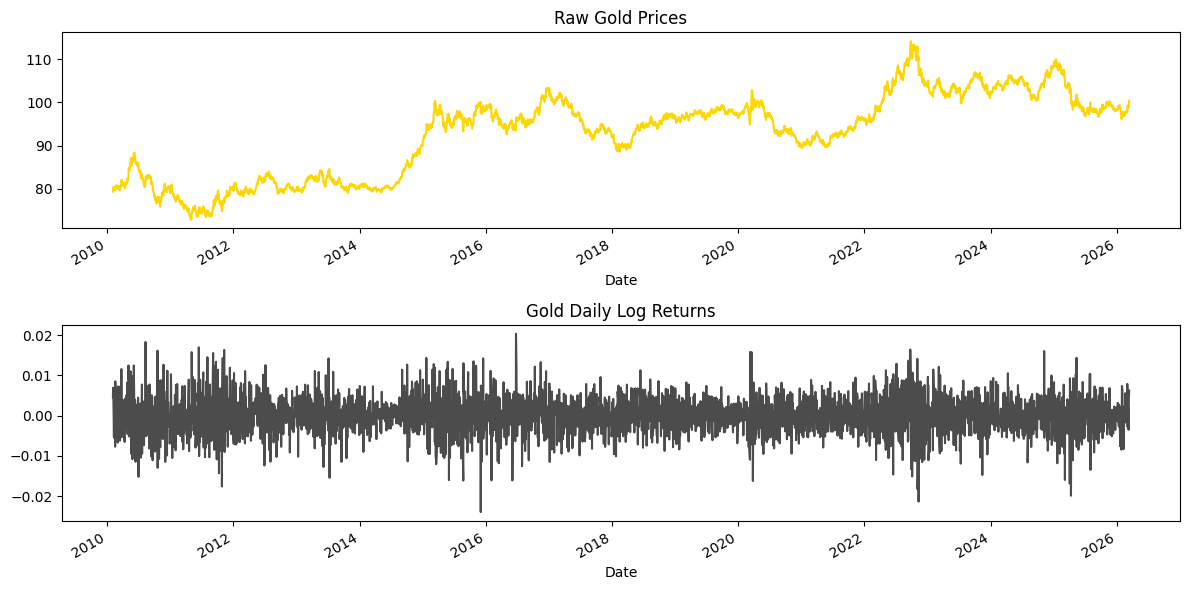

In [3]:
#Graphical Representation of Gold Values
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
df['gold'].plot(ax=axes[0], title="Raw Gold Prices", color='gold')
df['au_returns'].plot(ax=axes[1], title="Gold Daily Log Returns", color='black', alpha=0.7)
plt.tight_layout()
plt.show()



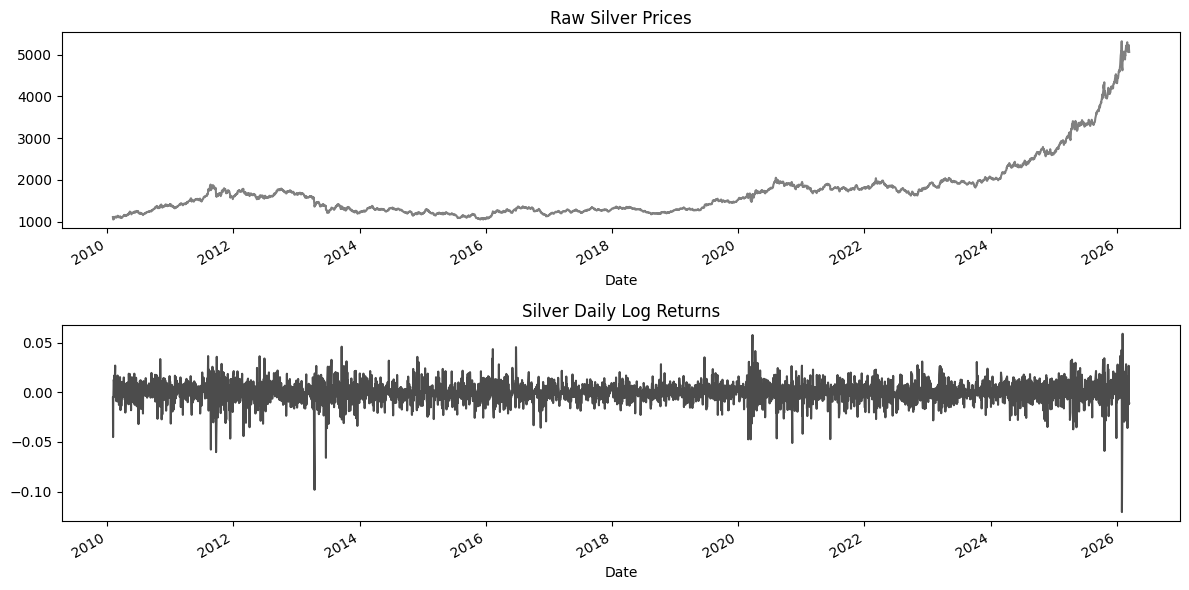

In [4]:
#Graphical Representation of Silver Values
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
df['silver'].plot(ax=axes[0], title="Raw Silver Prices", color='grey')
df['ag_returns'].plot(ax=axes[1], title="Silver Daily Log Returns", color='black', alpha=0.7)
plt.tight_layout()
plt.show()

Time Series Diagonistics

ADF Statistic: -62.7767, P-value: 0.0000
Series is Stationary
KPSS Statistic: 0.0610, P-value: 0.1000

--- VOLATILITY CLUSTERING TEST ---
ARCH Test p-value: 0.0000
Result: Strong evidence of volatility clustering (ARCH effects present).


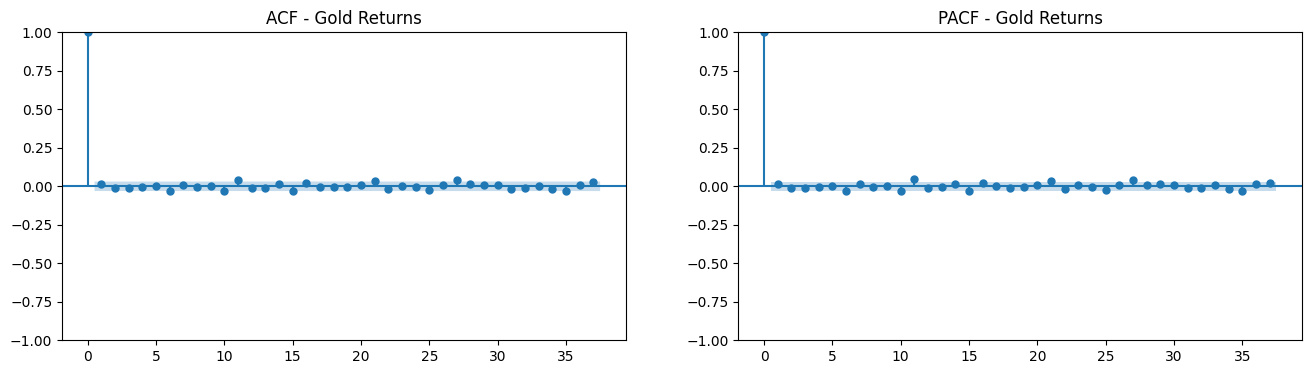

In [5]:
#GOLD
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings('ignore', category=InterpolationWarning)

#ADF Test
adf_result= adfuller(df['au_returns'])
print(f"ADF Statistic: {adf_result[0]:.4f}, P-value: {adf_result[1]:.4f}")
if adf_result[1] <= 0.05:
  print("Series is Stationary")

else:
  print("Series is Non-Stationary, Failed to reject null")

#KPSS Test
kpss_result= kpss(df['au_returns'], regression='c', nlags='auto')
print(f"KPSS Statistic: {kpss_result[0]:.4f}, P-value: {kpss_result[1]:.4f}")

print("\n--- VOLATILITY CLUSTERING TEST ---")
# 3. ARCH Test for heteroskedasticity (crucial for your GARCH model later)
arch_test = het_arch(df['au_returns'])
print(f"ARCH Test p-value: {arch_test[1]:.4f}")
if arch_test[1] < 0.05:
    print("Result: Strong evidence of volatility clustering (ARCH effects present).")

# 4. ACF and PACF Plots
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['au_returns'], ax=ax[0], title="ACF - Gold Returns")
plot_pacf(df['au_returns'], ax=ax[1], title="PACF - Gold Returns")
plt.show()

ADF Statistics for Silver: -65.9212, p-value: 0.0000
Series is Stationary
KPSS Statistic: 0.6384, P-value: 0.0191
ARCH Test p-value: 0.0000
Result: Strong evidence of volatility clustering (ARCH effects present).


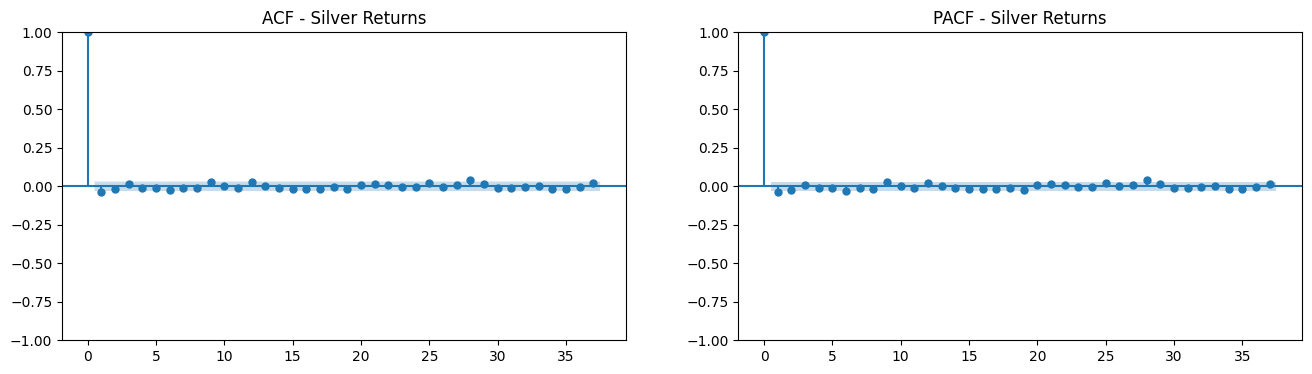

<Figure size 640x480 with 0 Axes>

In [6]:
#SILVER
#adf
adf_result_ag= adfuller(df['ag_returns'])
print(f"ADF Statistics for Silver: {adf_result_ag[0]:.4f}, p-value: {adf_result_ag[1]:.4f}")
if adf_result_ag[1] <= 0.05:
  print("Series is Stationary")

else:
  print('Non-Stationary Series')


#kpss
kpss_result_ag= kpss(df['ag_returns'], regression='c', nlags='auto')
print(f"KPSS Statistic: {kpss_result_ag[0]:.4f}, P-value: {kpss_result_ag[1]:.4f}")

#arch test
arch_test_ag = het_arch(df['ag_returns'])
print(f"ARCH Test p-value: {arch_test[1]:.4f}")
if arch_test_ag[1] < 0.05:
    print("Result: Strong evidence of volatility clustering (ARCH effects present).")

#acf and pacf plotting
fig, ax= plt.subplots(1,2, figsize=(16,4))
plot_acf(df['ag_returns'], ax=ax[0], title="ACF - Silver Returns")
plot_pacf(df['ag_returns'], ax=ax[1], title="PACF - Silver Returns")
plt.show()
plt.tight_layout()